In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import calendar
warnings.filterwarnings('ignore')

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# Base fipe historica
fipe_path = 'dados_fipe_tratados.csv'
# Base da taxa de cambio
exchange_path = 'DEXBZUS.csv'
# Base IPCA
ipca_path = 'bcdata.sgs.433.csv' 
# Adicionar PIB

df_fipe = pd.read_csv(fipe_path)
print('FIPE shape:', df_fipe.shape)
print(df_fipe.head())

df_ex = pd.read_csv(exchange_path)
print('DEXBZUS head:')
print(df_ex.head())

df_ipca = pd.read_csv(ipca_path, sep=';', decimal=',')
print('IPCA head:')
print(df_ipca.head())

FIPE shape: (278943, 8)
  reference_date brand_name          model_name  year fuel_name  brl_price  \
0     2023-09-01       Fiat           147 C/ CL  1987  Gasolina     4630.0   
1     2023-09-01       Fiat           147 C/ CL  1986  Gasolina     4478.0   
2     2023-09-01       Fiat           147 C/ CL  1985  Gasolina     3898.0   
3     2023-09-01       Fiat  147 Furgão (todos)  1987  Gasolina     2637.0   
4     2023-09-01       Fiat  147 Furgão (todos)  1986  Gasolina     2528.0   

   year_of_reference month_of_reference  
0               2023          September  
1               2023          September  
2               2023          September  
3               2023          September  
4               2023          September  
DEXBZUS head:
  observation_date  DEXBZUS
0       1995-01-02    0.844
1       1995-01-03    0.845
2       1995-01-04    0.845
3       1995-01-05    0.843
4       1995-01-06    0.840
IPCA head:
         data  valor
0  01/01/1980   6.62
1  01/02/1980   4.62

In [2]:

# --- Limpeza FIPE ---
# Converte nomes de meses para números
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}

df_fipe['month_num'] = df_fipe['month_of_reference'].map(month_map)
# Cria coluna de data (primeiro dia do mes)
df_fipe['date'] = pd.to_datetime(df_fipe['year_of_reference'].astype(str) + '-' + df_fipe['month_num'].astype(str) + '-01')

duplicates = df_fipe.duplicated().sum()
missing = df_fipe.isnull().sum()
print('Duplicados FIPE:', duplicates)
print('Valores ausentes FIPE:', missing)

# --- Limpeza taxa de cambio ---
if 'observation_date' in df_ex.columns:
    df_ex['date'] = pd.to_datetime(df_ex['observation_date'])
else:
    df_ex['date'] = pd.to_datetime(df_ex.iloc[:, 0])

exchange_col = [col for col in df_ex.columns if col not in ['date','observation_date']][0]
df_ex[exchange_col] = pd.to_numeric(df_ex[exchange_col], errors='coerce')

df_ex['date'] = pd.to_datetime(df_ex['observation_date'])

df_ex['DEXBZUS'] = pd.to_numeric(df_ex['DEXBZUS'], errors='coerce')

# Agrega para fazer a media mensal
df_ex_monthly = (
    df_ex[['date', 'DEXBZUS']]
    .set_index('date')
    .resample('ME')
    .mean()
    .reset_index()
)
df_ex_monthly.rename(columns={'DEXBZUS': 'exchange_rate'}, inplace=True)

# --- Limpeza IPCA ---
if df_ipca.columns.tolist()[0].strip().lower() == '"data"' or 'data' in df_ipca.columns[0]:
    df_ipca.columns = ['data','valor']
try:
    df_ipca['date'] = pd.to_datetime(df_ipca['data'], dayfirst=True)
except:
    df_ipca['date'] = pd.to_datetime(df_ipca['data'].str.replace('"',''), dayfirst=True)
df_ipca['ipca'] = df_ipca['valor'].astype(str).str.replace('"','').str.replace('.', '')
df_ipca['ipca'] = df_ipca['ipca'].str.replace(',', '.').astype(float)
df_ipca_monthly = df_ipca[['date','ipca']].copy()
df_ipca_monthly['date'] = df_ipca_monthly['date'].dt.to_period('M').dt.to_timestamp('M')

print('Amostra IPCA mensal:')
print(df_ipca_monthly.head())

Duplicados FIPE: 0
Valores ausentes FIPE: reference_date        0
brand_name            0
model_name            0
year                  0
fuel_name             0
brl_price             0
year_of_reference     0
month_of_reference    0
month_num             0
date                  0
dtype: int64
Amostra IPCA mensal:
        date   ipca
0 1980-01-31  662.0
1 1980-02-29  462.0
2 1980-03-31  604.0
3 1980-04-30  529.0
4 1980-05-31   57.0


In [4]:

# Alinha variaveis macroeconomicas para o mesmo periodo
# Ajusta datas para fim do mes no FIPE para combinar mais facilmente com IPCA e cambio
fipe_monthly = df_fipe.copy()
fipe_monthly['date'] = fipe_monthly['date'].dt.to_period('M').dt.to_timestamp('M')

# Junta com taxa de cambio
merged = fipe_monthly.merge(df_ex_monthly, on='date', how='left')

# Junta com IPCA
merged = merged.merge(df_ipca_monthly, on='date', how='left')

merged.drop(columns=['month_of_reference','month_num'], inplace=True)

print('Shape merged:', merged.shape)
print(merged[['date','brand_name','model_name','brl_price','exchange_rate','ipca']].head())

# Retira linhas sem preço ou variaveis macro
merged = merged.dropna(subset=['brl_price','exchange_rate','ipca'])

Shape merged: (278943, 10)
        date brand_name          model_name  brl_price  exchange_rate  ipca
0 2023-09-30       Fiat           147 C/ CL     4630.0       4.938665  26.0
1 2023-09-30       Fiat           147 C/ CL     4478.0       4.938665  26.0
2 2023-09-30       Fiat           147 C/ CL     3898.0       4.938665  26.0
3 2023-09-30       Fiat  147 Furgão (todos)     2637.0       4.938665  26.0
4 2023-09-30       Fiat  147 Furgão (todos)     2528.0       4.938665  26.0


In [ ]:
# TODO Novas Feature engineering
# Separar veiculos em luxo e popular
# engine_size
# gear
merged['age_years'] = merged['year_of_reference'] - merged['year']

In [78]:
df_ipca_monthly['ipca'].describe()

count     555.000000
mean      513.446847
std      1027.363011
min       -68.000000
25%        32.000000
50%        64.000000
75%       530.000000
max      8239.000000
Name: ipca, dtype: float64

In [80]:
df_ipca_monthly[df_ipca_monthly['date'].dt.year >= 2023]['ipca'].describe()

count     39.000000
mean      37.769231
std       28.198975
min      -11.000000
25%       22.000000
50%       33.000000
75%       52.500000
max      131.000000
Name: ipca, dtype: float64

In [83]:
df_ex_monthly['exchange_rate'].describe()

count    376.000000
mean       2.885745
std        1.436537
min        0.841150
25%        1.802882
50%        2.374510
75%        3.802984
max        6.100971
Name: exchange_rate, dtype: float64

In [82]:
df_ex_monthly[df_ex_monthly['date'].dt.year >= 2023]['exchange_rate'].describe()

count    40.000000
mean      5.313523
std       0.337885
min       4.800480
25%       5.011458
50%       5.280630
75%       5.544280
max       6.100971
Name: exchange_rate, dtype: float64

Distribuição de preços (R$):
count    271451.000000
mean      43775.398654
std       48222.711918
min        2018.000000
25%       15608.000000
50%       30012.000000
75%       53020.500000
max      775780.000000
Name: brl_price, dtype: float64
Estatistica de preço por marca
                         mean  count
brand_name                          
VW - VolksWagen  39424.436141  96799
GM - Chevrolet   52713.529586  87372
Fiat             39653.336835  87280


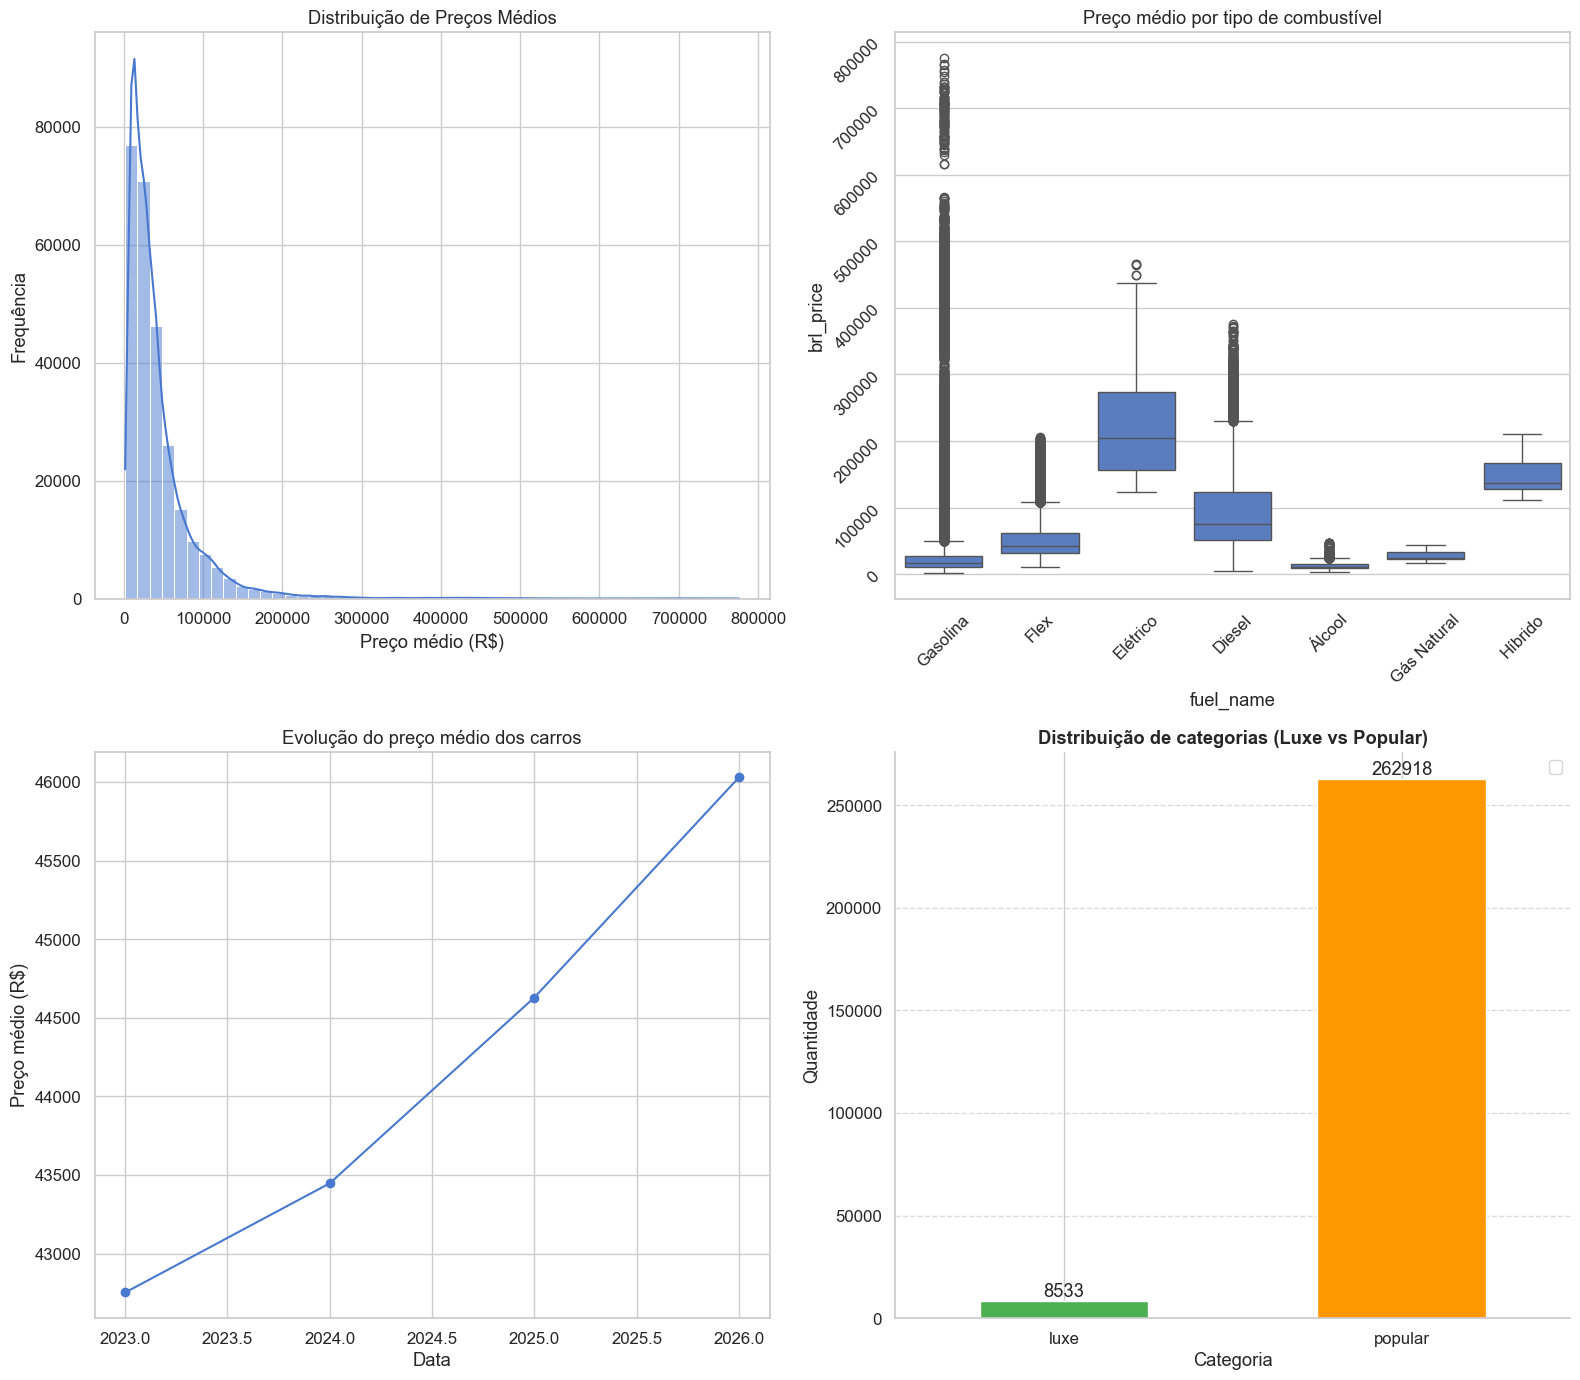

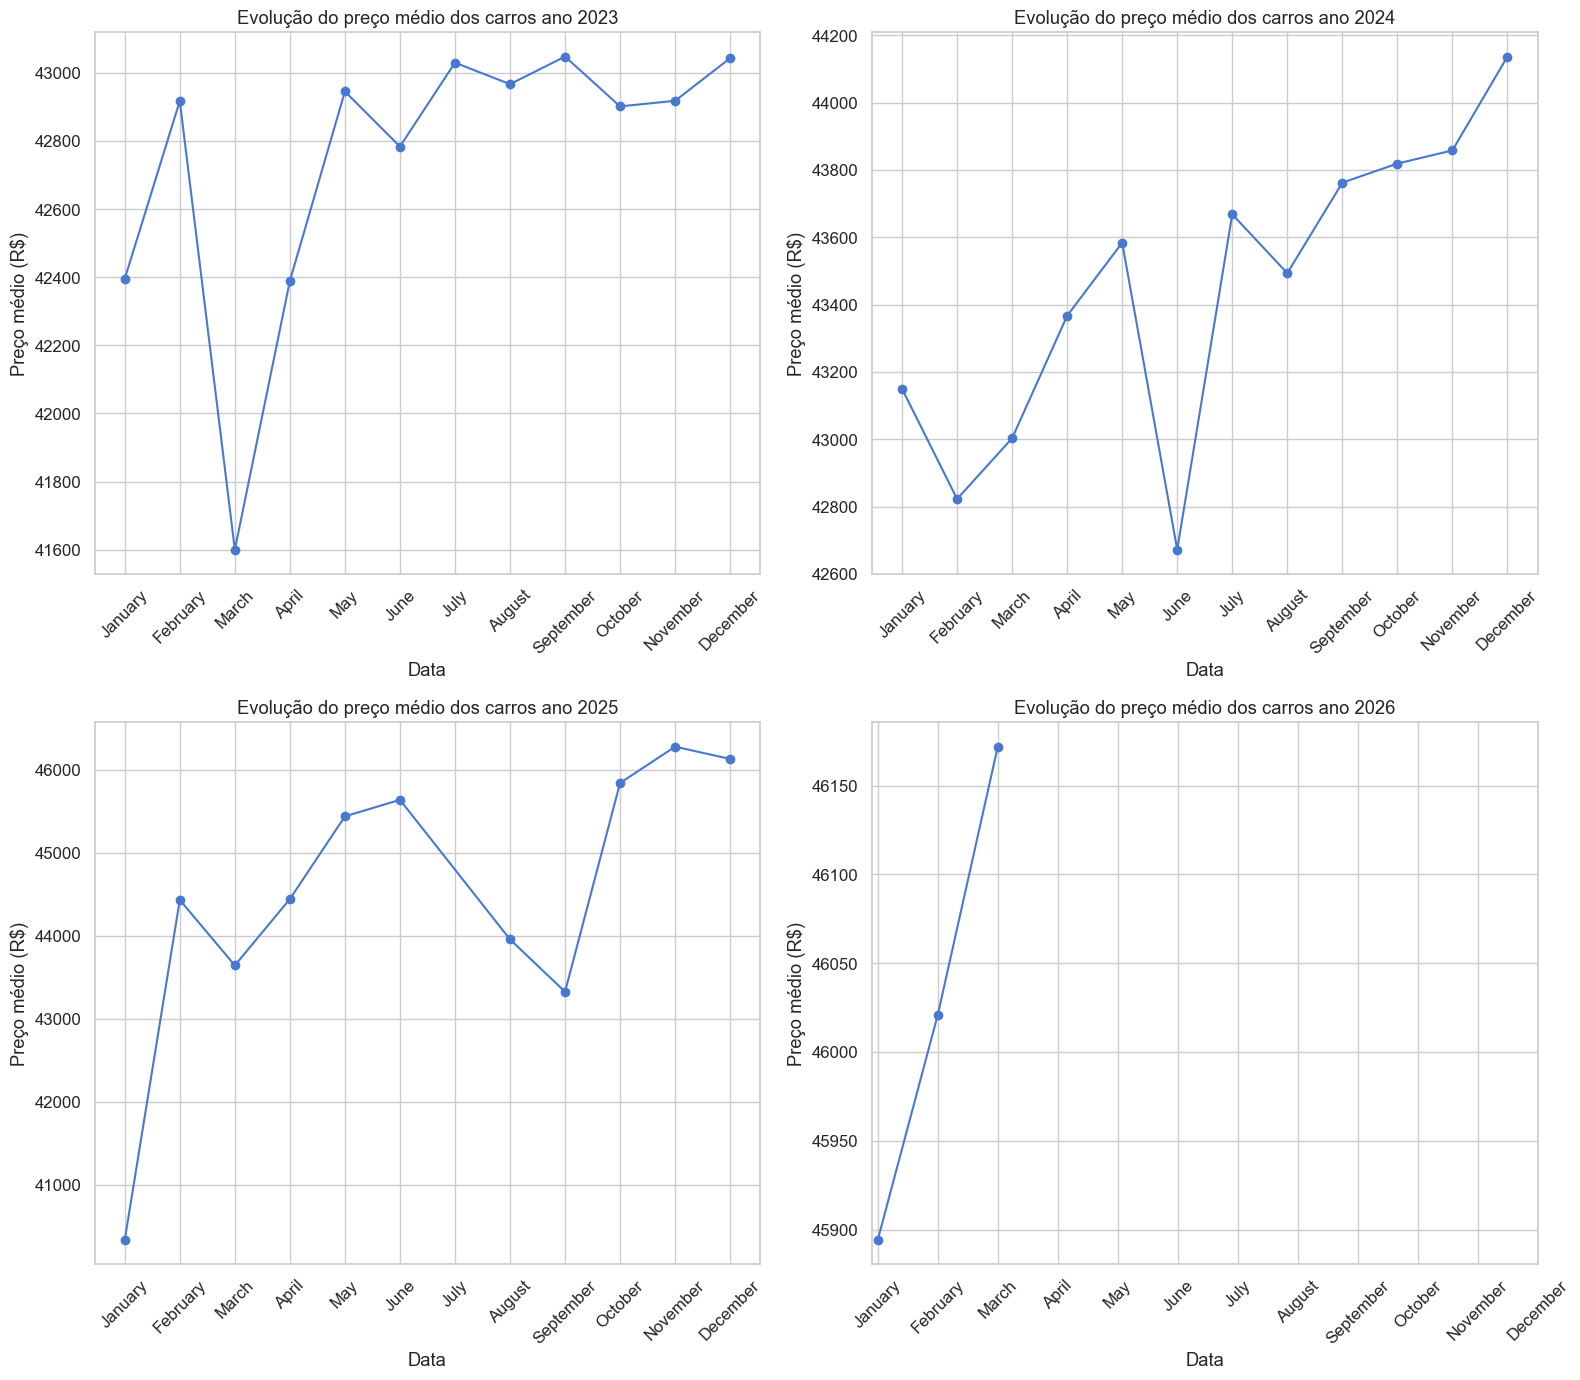

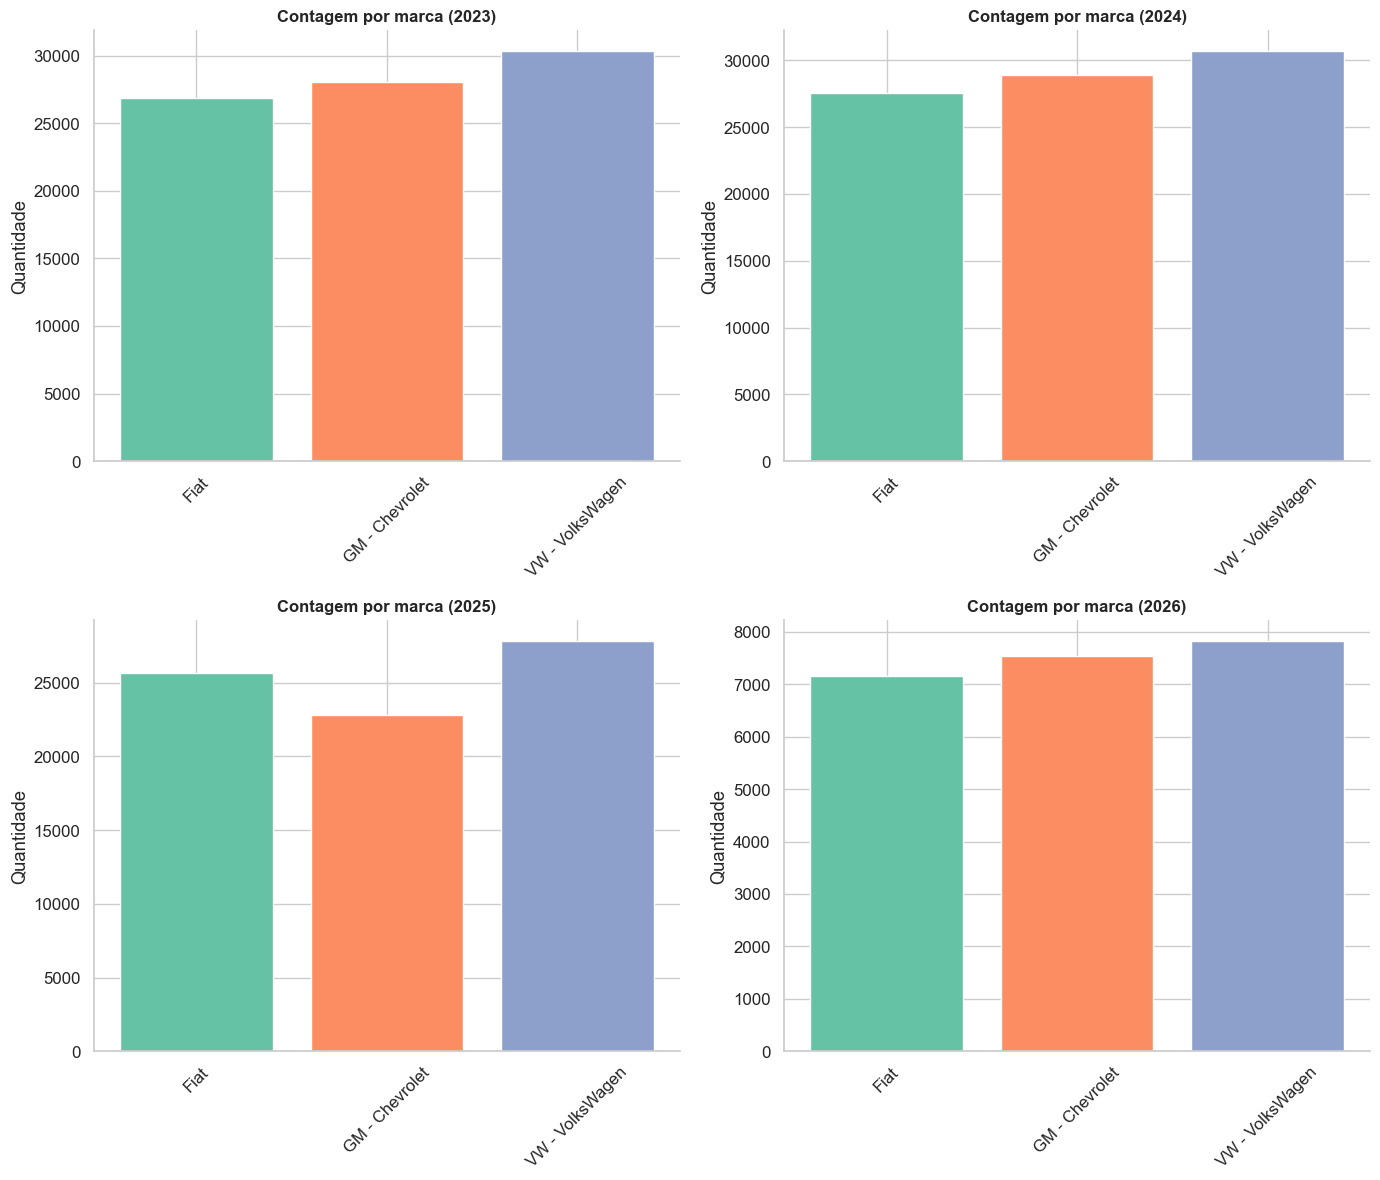

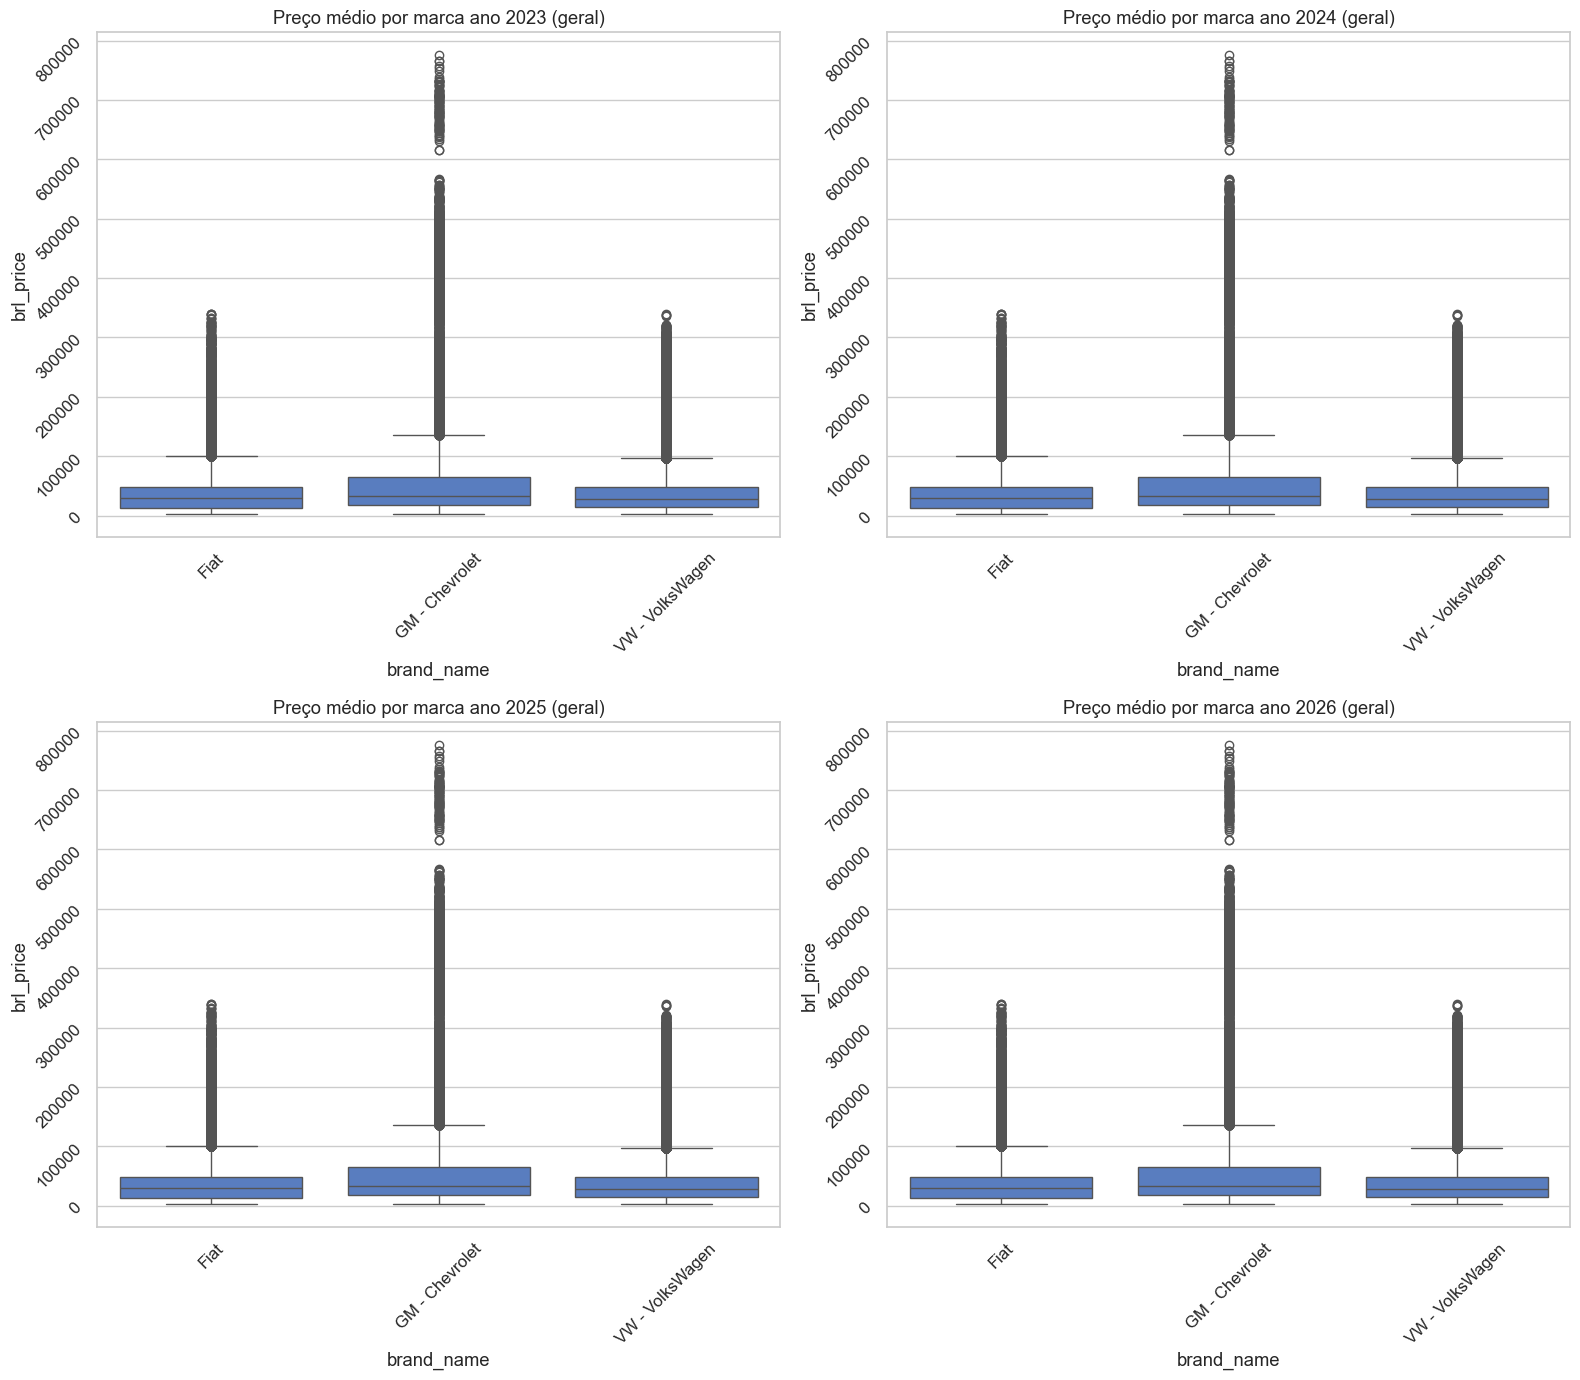

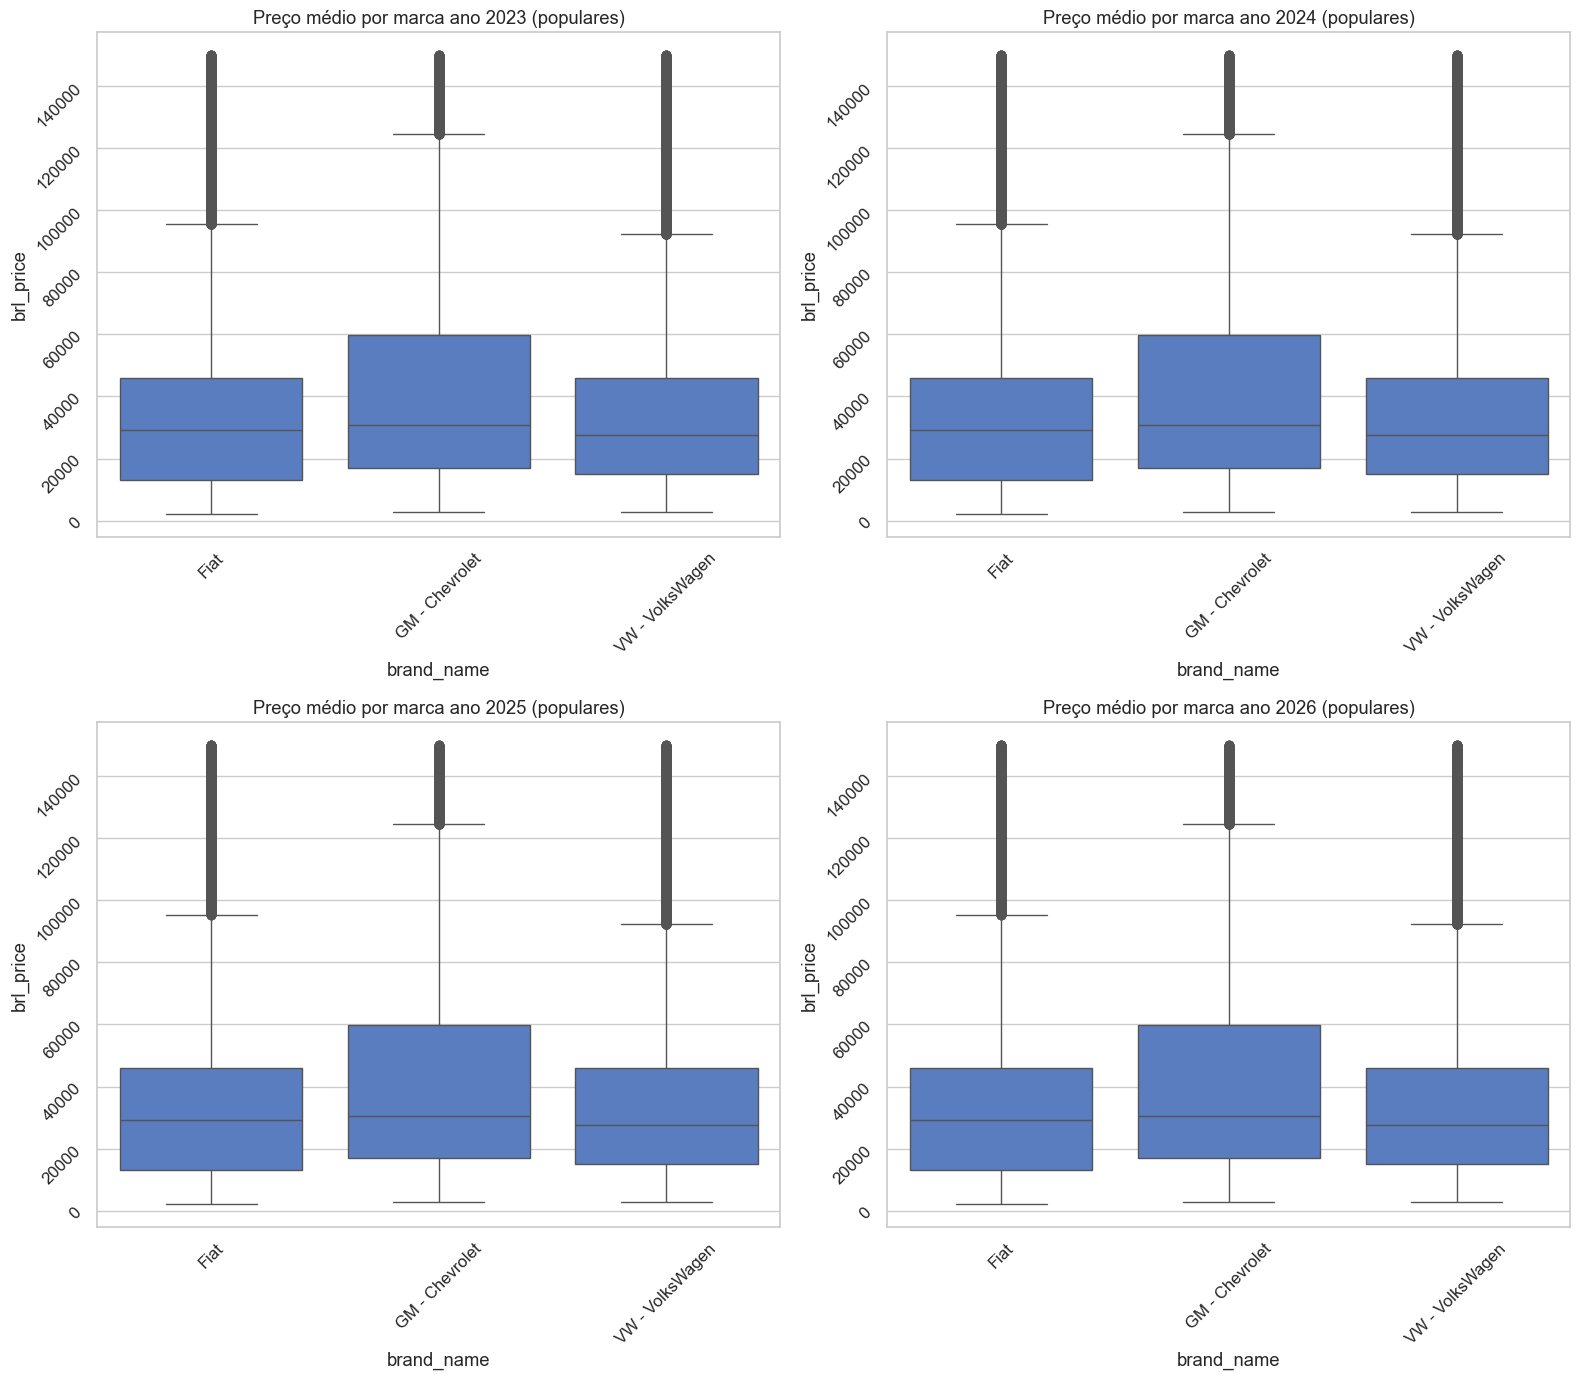

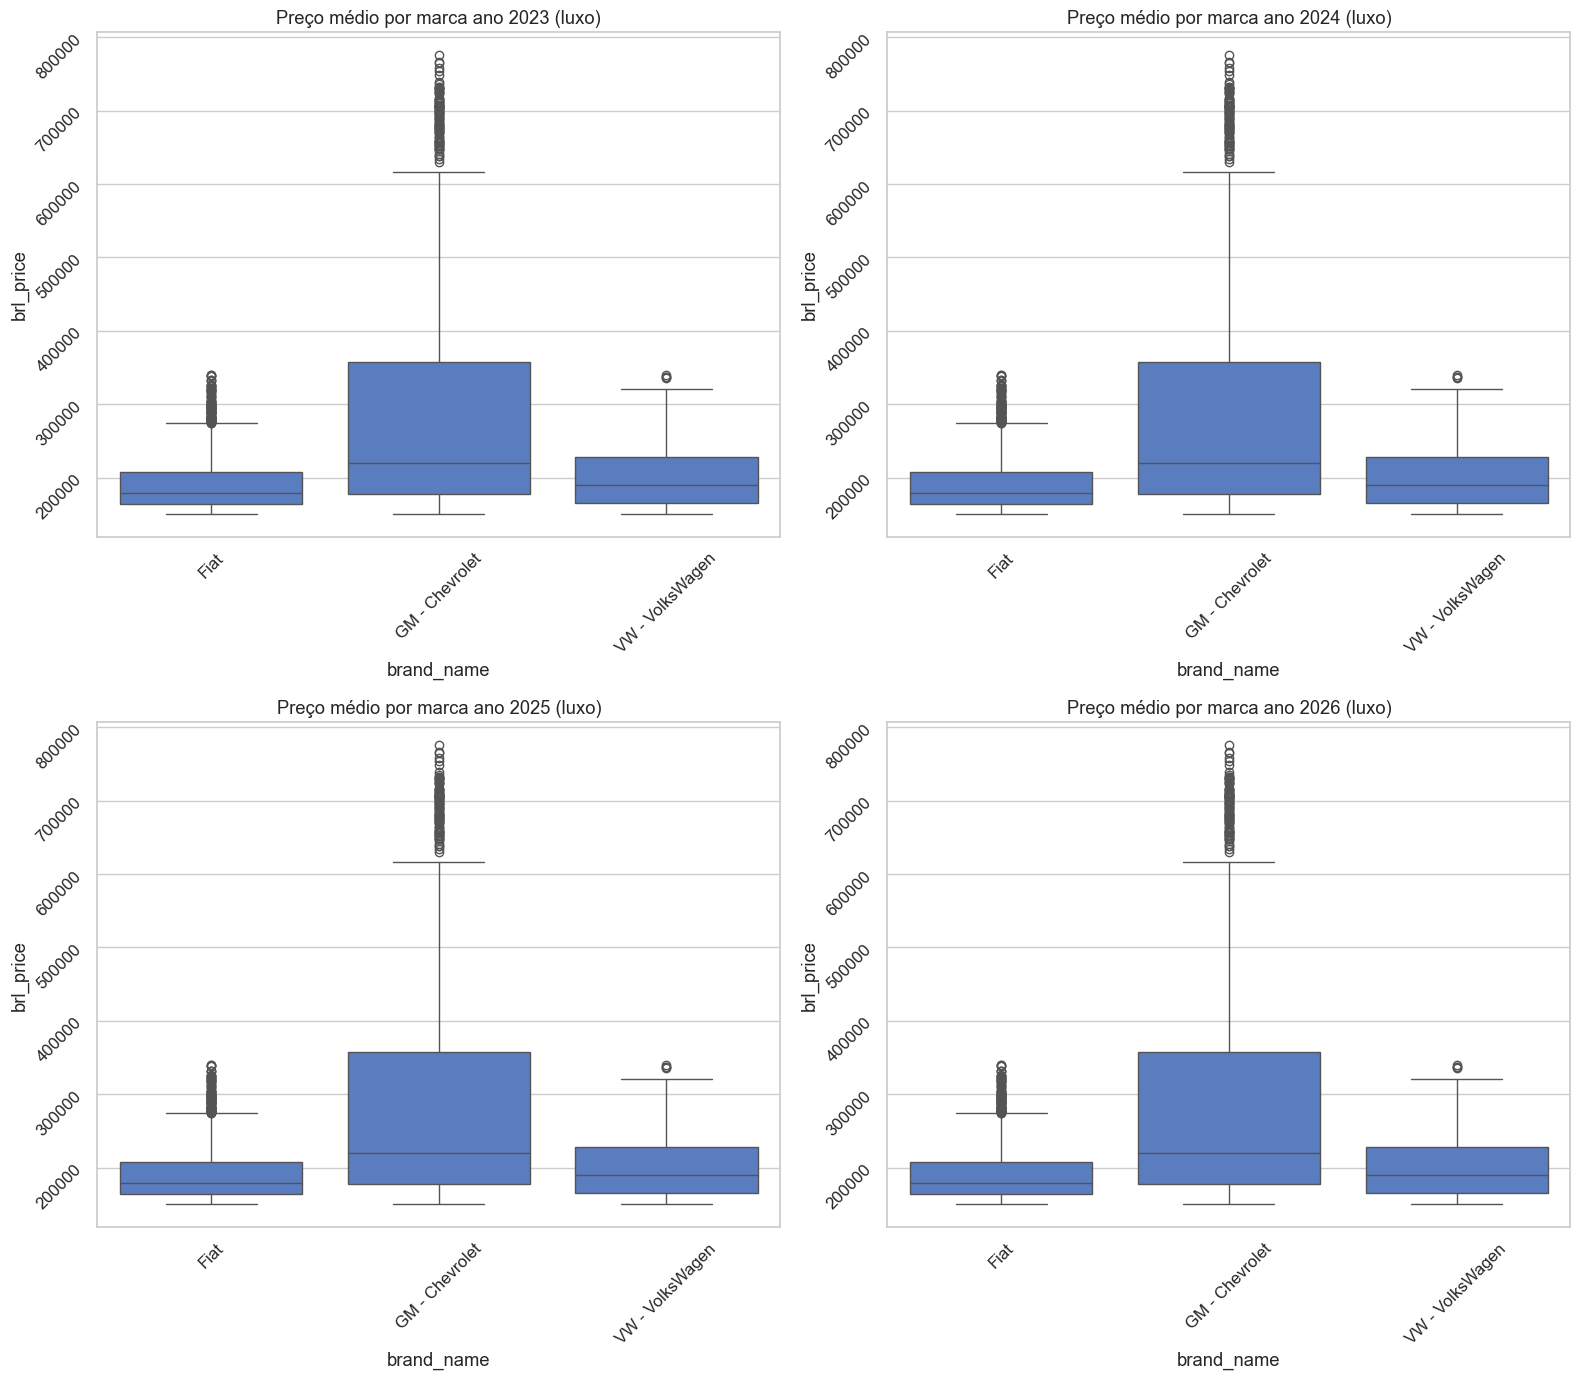

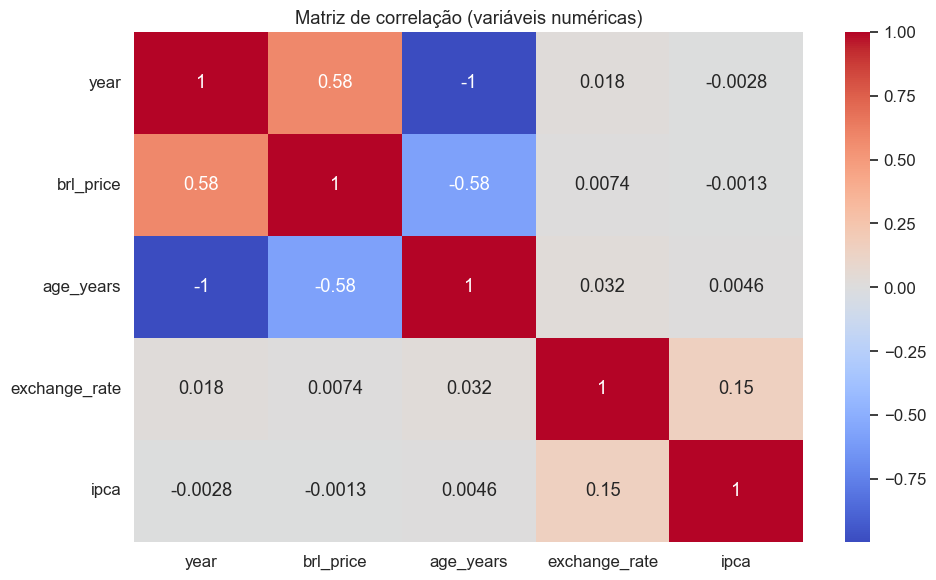

In [72]:

# Estatisticas descritivas
print('Distribuição de preços (R$):')
print(merged['brl_price'].describe())

# Distribuicao por marca
brand_stats = merged.groupby('brand_name')['brl_price'].agg(['mean','count']).sort_values('count', ascending=False)
print("Estatistica de preço por marca")
print(brand_stats)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))

# Histograma do preco medio
sns.histplot(merged['brl_price'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribuição de Preços Médios')
axes[0,0].set_xlabel('Preço médio (R$)')
axes[0,0].set_ylabel('Frequência')

# Boxplot por categoria de combustivel
sns.boxplot(x='fuel_name', y='brl_price', data=merged, ax=axes[0, 1])
axes[0,1].set_title('Preço médio por tipo de combustível')
axes[0,1].tick_params(rotation=45)

# Evolucao temporal media
merged.groupby('year_of_reference')['brl_price'].mean().plot(marker='o', ax=axes[1, 0])
axes[1,0].set_title('Evolução do preço médio dos carros')
axes[1,0].set_xlabel('Data')
axes[1,0].set_ylabel('Preço médio (R$)')

# Veiculos de luxo x populares
merged_temp = merged.copy()
merged_temp['category'] = np.where(
    merged_temp['brl_price'] >= 150000,
    'luxe',
    'popular'
)
ax = axes[1, 1]

serie = merged_temp.groupby('category').size()

colors = ['#4CAF50', '#FF9800']

serie.plot(kind='bar', ax=ax, color=colors)

ax.set_title('Distribuição de categorias (Luxe vs Popular)', weight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('Quantidade')

ax.tick_params(axis='x', rotation=0)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for i, v in enumerate(serie.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))

for i, ano in enumerate([2023, 2024, 2025, 2026]):
    merged_temp = merged.copy()
    merged_temp = merged_temp[merged_temp['date'].dt.year == ano]
    ax = axes[i // 2, i % 2]
    serie = merged_temp.groupby(merged_temp['date'].dt.month)['brl_price'].mean()
    serie.plot(marker='o', ax=ax)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(list(calendar.month_name)[1:])

    ax.set_title(f'Evolução do preço médio dos carros ano {ano}')
    ax.set_xlabel('Data')
    ax.set_ylabel('Preço médio (R$)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

brands = merged['brand_name'].unique()
palette = sns.color_palette("Set2", len(brands))
color_map = dict(zip(brands, palette))

for i, ano in enumerate([2023, 2024, 2025, 2026]):
    merged_temp = merged.copy()
    merged_temp = merged_temp[merged_temp['date'].dt.year == ano]
    ax = axes[i // 2, i % 2]
    serie = (
        merged_temp.groupby('brand_name')
        .size()
        .reindex(brands, fill_value=0)
    )

    colors = [color_map[b] for b in serie.index]

    bars = ax.bar(serie.index, serie.values, color=colors)

    ax.set_title(f'Contagem por marca ({ano})', fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Quantidade')

    ax.tick_params(axis='x', rotation=45)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))

for i, ano in enumerate([2023, 2024, 2025, 2026]):
    # Boxplot por marca
    ax = axes[i // 2, i % 2]
    sns.boxplot(x='brand_name', y='brl_price', data=merged, ax=ax)
    ax.set_title(f'Preço médio por marca ano {ano} (geral)')
    ax.tick_params(rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))

for i, ano in enumerate([2023, 2024, 2025, 2026]):
    merged_temp = merged.copy()
    merged_temp = merged_temp[merged_temp['brl_price'] < 150000]
    # Boxplot por marca
    ax = axes[i // 2, i % 2]
    sns.boxplot(x='brand_name', y='brl_price', data=merged_temp, ax=ax)
    ax.set_title(f'Preço médio por marca ano {ano} (populares)')
    ax.tick_params(rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))

for i, ano in enumerate([2023, 2024, 2025, 2026]):
    merged_temp = merged.copy()
    merged_temp = merged_temp[merged_temp['brl_price'] >= 150000]
    # Boxplot por marca
    ax = axes[i // 2, i % 2]
    sns.boxplot(x='brand_name', y='brl_price', data=merged_temp, ax=ax)
    ax.set_title(f'Preço médio por marca ano {ano} (luxo)')
    ax.tick_params(rotation=45)

plt.tight_layout()
plt.show()

# Correlacao variaveis numericas
num_cols = ['year','brl_price','age_years','exchange_rate','ipca']
corr = merged[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlação (variáveis numéricas)')

plt.tight_layout()
plt.show()